In [22]:
import pandas as pd
import matplotlib.pyplot as plt


allele_frequencies_path = "allele_frequencies.txt"
quality_scores_path = "quality_scores.txt"
depth_path = "depth.txt"


allele_freqs = pd.read_csv(allele_frequencies_path, sep="\t", header=None, names=["Frequency"])
quality_scores = pd.read_csv(quality_scores_path, sep="\t", header=None, names=["Quality"])
depth = pd.read_csv(depth_path, sep="\t", header=None, names=["Chromosome", "Position", "Depth"])

#summary statistics
allele_freq_stats = allele_freqs.describe()
quality_scores_stats = quality_scores.describe()
depth_stats = depth["Depth"].describe()

#relevant statistics
rare_variants = (allele_freqs["Frequency"] < 0.05).sum()
low_coverage = (depth["Depth"] < 10).sum()

print("=== Allele Frequency Statistics ===")
print(allele_freq_stats)
print(f"Rare Variants (Frequency < 0.05): {rare_variants}")

print("\n=== Quality Scores Statistics ===")
print(quality_scores_stats)

print("\n=== Depth of Coverage Statistics ===")
print(depth_stats)
print(f"Low Coverage Sites (Depth < 10): {low_coverage}")


=== Allele Frequency Statistics ===
          Frequency
count  73805.000000
mean       2.222299
std        0.911464
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max       26.000000
Rare Variants (Frequency < 0.05): 0

=== Quality Scores Statistics ===
            Quality
count  73805.000000
mean      68.758435
std      213.628077
min       30.010000
25%       46.990000
50%       51.050000
75%       73.050000
max    24788.500000

=== Depth of Coverage Statistics ===
count    73805.000000
mean         4.766249
std          7.288877
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max        597.000000
Name: Depth, dtype: float64
Low Coverage Sites (Depth < 10): 71020


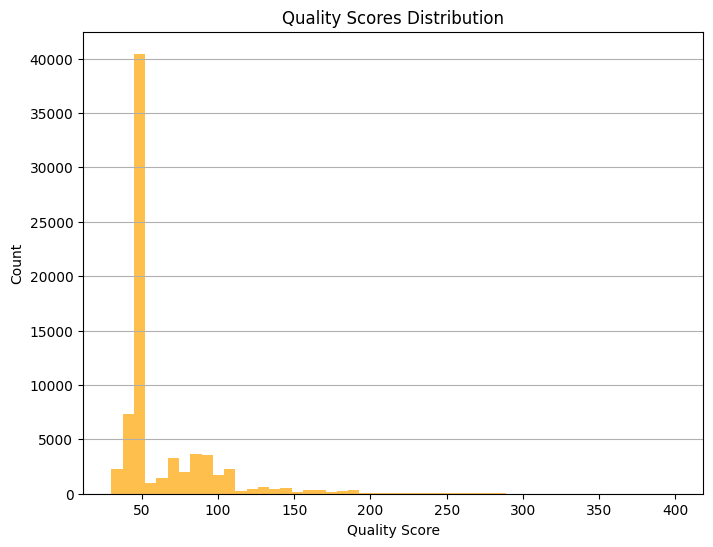

In [23]:
# Filter quality scores
quality_scores_filtered = quality_scores[quality_scores["Quality"] < 400]

# Quality Scores Histogram (Filtered)
plt.figure(figsize=(8, 6))
plt.hist(quality_scores_filtered["Quality"], bins=50, color='orange', alpha=0.7)
plt.title("Quality Scores Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.grid(axis='y')
plt.savefig("QualityScore.png", dpi=300)
plt.show()


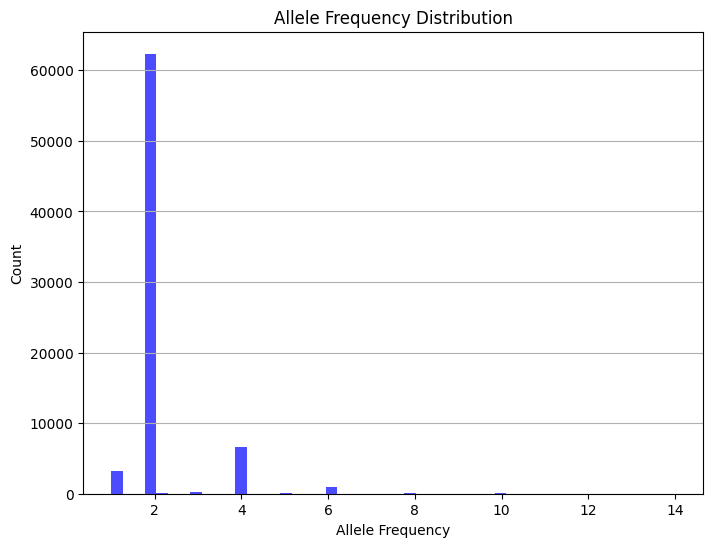

In [24]:
filtered_frequency = allele_freqs[allele_freqs["Frequency"]<15]

plt.figure(figsize=(8, 6))
plt.hist(filtered_frequency["Frequency"], bins=50, color='blue', alpha=0.7)
plt.title("Allele Frequency Distribution")
plt.xlabel("Allele Frequency")
plt.ylabel("Count")
plt.grid(axis='y')
plt.savefig("allele_freq.png", dpi=300)
plt.show()

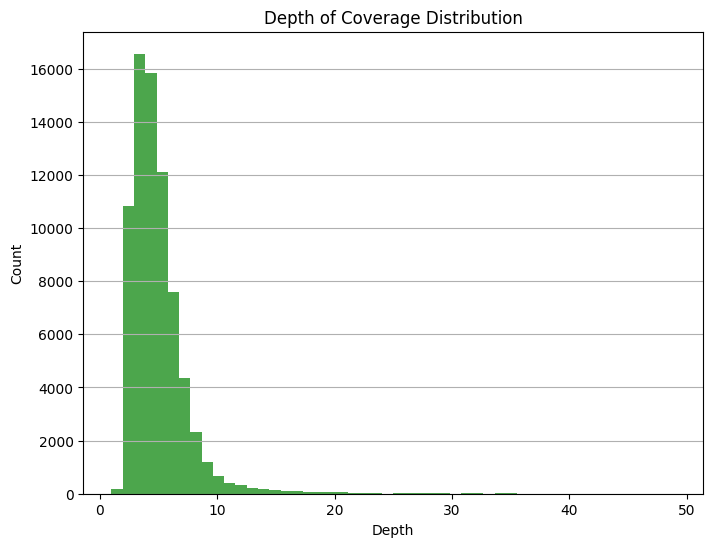

In [25]:
depth_filter = depth[depth["Depth"]<50]

plt.figure(figsize=(8, 6))
plt.hist(depth_filter["Depth"], bins=50, color='green', alpha=0.7)
plt.title("Depth of Coverage Distribution")
plt.xlabel("Depth")
plt.ylabel("Count")
plt.grid(axis='y')
plt.savefig("depth.png", dpi=300)
plt.show()